# 2. Backtest: reconstructed S&P 500 vs SPY, ^GSPC and a Magnificent-8 book

Uses the data loaded by notebook **01**. The question: does our float-adjusted, market-cap-weighted
reconstruction of the S&P 500 track the real thing (the SPY ETF and the ^GSPC index level)? And how does a
concentrated **MAG8** thesis book compare with the broad market?

Everything is computed from stored holdings and prices:

| Step | Library call |
|---|---|
| Join portfolios → holdings → prices → shares outstanding | `database.get_portfolio_market_data` |
| Constituent returns | `analytics.portfolio.calculate_portfolio_constituent_returns` |
| Constituent weights (market / equal / price weighted, optional cap) | `analytics.portfolio.calculate_portfolio_constituent_weights` |
| Portfolio returns and statistics | `analytics.backtest.reconstruction_backtest` |
| Value at risk | `analytics.risk.risk_analytics.PortfolioVaR` |

## 2.1 Parameters and data

In [1]:
import pandas as pd
from IPython.display import display

import sys
import os

# Make the project root importable (notebook launched from toolkit/notebooks,
# where  /  are not on the path by default).
_root = os.path.dirname(os.path.dirname(os.getcwd()))
if _root not in sys.path:
    sys.path.insert(0, _root)

from analytics.backtest import reconstruction_backtest

from analytics.performance.plots import plot_cumulative_returns, plot_drawdowns
from analytics.portfolio import calculate_portfolio_constituent_returns, calculate_portfolio_constituent_weights
from analytics.risk.risk_analytics import PortfolioVaR
from data_engineering.database import database

START_DATE, END_DATE = "2023-01-01", "2026-08-31"
PORTFOLIOS = ["SPY", "SP500", "MAG8", "GSPC"]
MAX_WEIGHT = 0.10          # cap on any single name in a market-weighted book (guards against a bad price print)
PRICE = "adj_close"

pd.set_option("display.width", 160)
engine, connection, conn_str, session = database.get_db_connection()
market_data = database.get_portfolio_market_data(session, engine, START_DATE, END_DATE, PORTFOLIOS)
print(f"{len(market_data):,} (date, portfolio, security) rows | {market_data['as_of_date'].nunique()} dates")

constituent_returns = calculate_portfolio_constituent_returns(market_data, PRICE)["returns"]


def backtest(weighting: str, portfolio_specific=None, max_weight=None):
    """Constituent weights for the chosen scheme -> per-portfolio daily returns."""
    weights = calculate_portfolio_constituent_weights(market_data, PRICE, weighting, portfolio_specific_weights=portfolio_specific, max_weight=max_weight)
    return reconstruction_backtest(constituent_returns, weights)

Database connection successful.
469,107 (date, portfolio, security) rows | 918 dates


## 2.2 Market-cap weighted

The `SP500` benchmark's weight on day *t* is float-adjusted shares × close, both taken at **t‑1**, so the weight
that earns day *t*'s return is the one an index fund actually held. SPY and GSPC are single-line portfolios;
MAG8 is weighted by held shares × prior close.

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,beta,correlation,tracking_error
GSPC,1.0099,0.2115,0.1478,1.3718,2.0427,-0.1890,1.1188,0.5594,917,NaN,NaN,NaN
MAG8,2.6625,0.4287,0.2148,1.7685,2.7497,-0.2436,1.7600,0.5594,917,1.2706,0.8743,0.1117
SP500,0.8780,0.1891,0.1464,1.2565,1.8569,-0.1905,0.9925,0.5583,917,0.9871,0.9970,0.0115
SPY,1.0142,0.2122,0.1505,1.3538,2.0283,-0.1900,1.1169,0.5649,917,1.0148,0.9967,0.0124


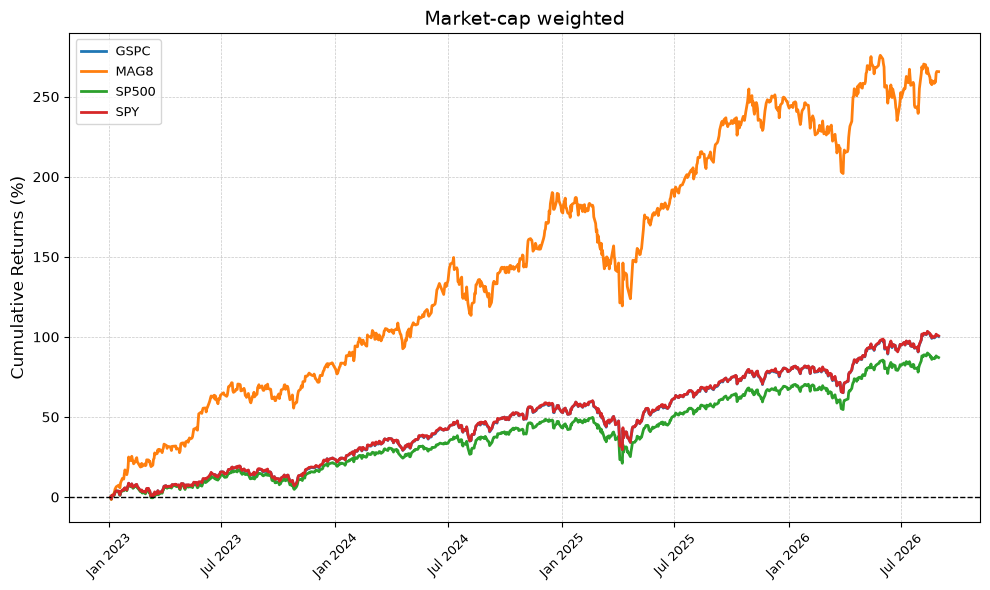

In [2]:
market = backtest("market_weighted", max_weight=MAX_WEIGHT)
display(market.summary(benchmark="GSPC").round(4))
display(plot_cumulative_returns(market.returns, title="Market-cap weighted"))

### How good is the reconstruction?

If the membership, float shares and prices are right, `SP500` should be almost indistinguishable from `GSPC`
(price index) and very close to `SPY` (which additionally earns dividends and pays a fee).

In [3]:
daily = market.returns
checks = pd.DataFrame({
    "corr_with_GSPC": daily.corrwith(daily["GSPC"]),
    "corr_with_SPY": daily.corrwith(daily["SPY"]),
    "tracking_error_vs_GSPC_pa": (daily.sub(daily["GSPC"], axis=0)).std() * 252 ** 0.5,
    "total_return": (1 + daily).prod() - 1,
})
display(checks.round(4))
gap = (daily["SP500"] - daily["GSPC"]).abs()
print("largest daily gaps between the reconstruction and ^GSPC (candidates for a bad price print):")
display(gap.sort_values(ascending=False).head(5).to_frame("abs_gap"))

,corr_with_GSPC,corr_with_SPY,tracking_error_vs_GSPC_pa,total_return
portfolio_short_name,,,,
GSPC,1.0000,0.9967,0.0000,1.0099
MAG8,0.8743,0.8690,0.1117,2.6625
SP500,0.9970,0.9941,0.0115,0.8780
SPY,0.9967,1.0000,0.0124,1.0142


largest daily gaps between the reconstruction and ^GSPC (candidates for a bad price print):


,abs_gap
as_of_date,
2024-02-22,0.006500
2023-05-25,0.005337
2024-04-19,0.005306
2024-05-23,0.005183
2024-05-28,0.003883


## 2.3 Equal weighted

In a market-cap index a 1 % move in Apple matters far more than a 1 % move in the 400th name; in an equal-weighted
index every company counts the same.

| Feature | Market-cap weighted | Equal weighted |
|---|---|---|
| Risk profile | Concentrated in mega-caps | Spread across mid / large caps |
| Return driver | The winners (e.g. MAG8) | Market breadth |
| Volatility | Usually lower | Usually higher |

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,beta,correlation,tracking_error
GSPC,1.0099,0.2115,0.1478,1.3718,2.0427,-0.1890,1.1188,0.5594,917,NaN,NaN,NaN
MAG8,3.9358,0.5507,0.2685,1.7685,2.7497,-0.2973,1.8524,0.5594,917,1.5882,0.8743,0.1567
SP500,0.6002,0.1379,0.1416,0.9831,1.4542,-0.1812,0.7612,0.5354,917,0.8308,0.8672,0.0748
SPY,1.0142,0.2122,0.1505,1.3538,2.0283,-0.1900,1.1169,0.5649,917,1.0148,0.9967,0.0124


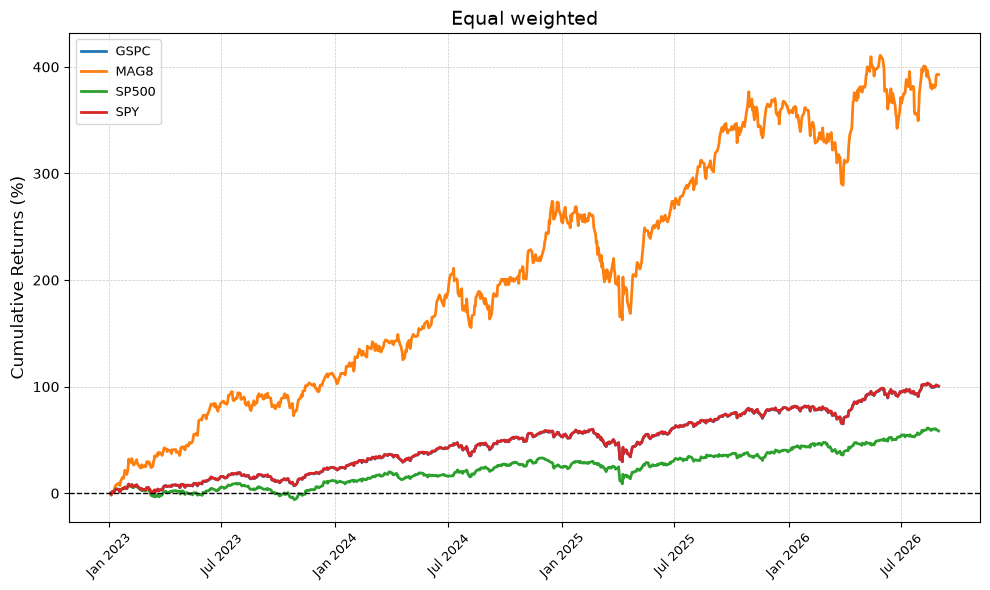

In [4]:
equal = backtest("equal_weighted")
display(equal.summary(benchmark="GSPC").round(4))
display(plot_cumulative_returns(equal.returns, title="Equal weighted"))

## 2.4 Mixed: equal-weighted MAG8 against the market-cap benchmark

The realistic comparison: an investor holds the eight names in equal weight and measures against the index.

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,beta,correlation,tracking_error
GSPC,1.0099,0.2115,0.1478,1.3718,2.0427,-0.1890,1.1188,0.5594,917,NaN,NaN,NaN
MAG8,3.9358,0.5507,0.2685,1.7685,2.7497,-0.2973,1.8524,0.5594,917,1.5882,0.8743,0.1567
SP500,0.8780,0.1891,0.1464,1.2565,1.8569,-0.1905,0.9925,0.5583,917,0.9871,0.9970,0.0115
SPY,1.0142,0.2122,0.1505,1.3538,2.0283,-0.1900,1.1169,0.5649,917,1.0148,0.9967,0.0124


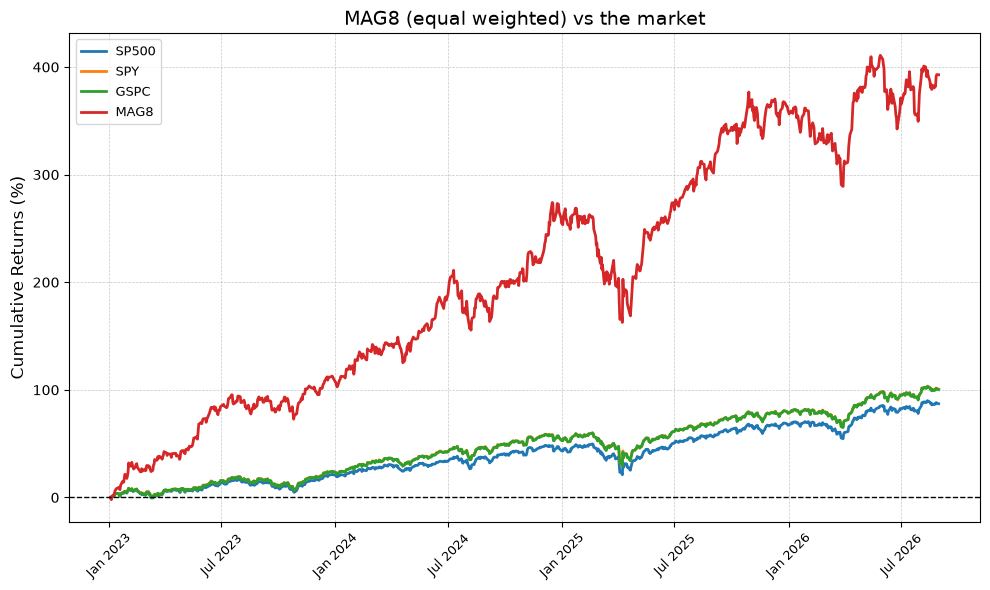

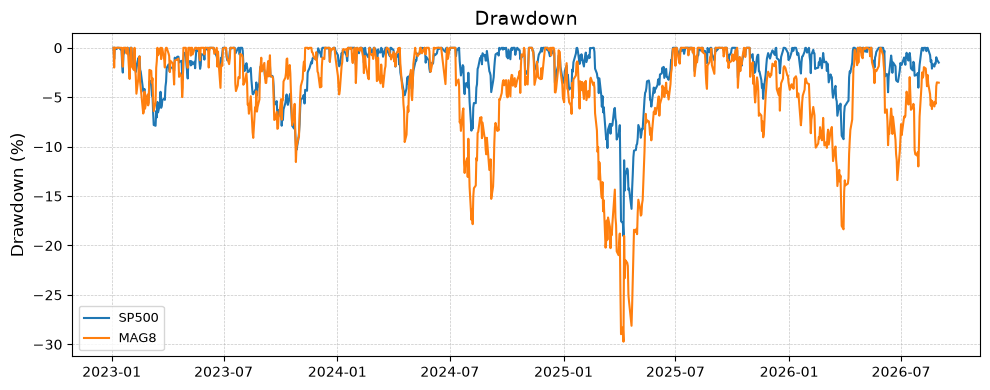

In [5]:
mixed = backtest("market_weighted", portfolio_specific={"MAG8": "equal_weighted"}, max_weight=MAX_WEIGHT)
display(mixed.summary(benchmark="GSPC").round(4))
display(plot_cumulative_returns(mixed.returns[["SP500", "SPY", "GSPC", "MAG8"]], title="MAG8 (equal weighted) vs the market"))
display(plot_drawdowns(mixed.returns[["SP500", "MAG8"]]))

## 2.5 Value at risk

Historical-simulation and parametric (variance–covariance) 1-day VaR from the constituents' returns and each
portfolio's latest weights. Parametric VaR assumes normality, so it usually looks *less* extreme than the
historical figure for concentrated books with fat-tailed constituents.

In [6]:
LOOKBACK_DAYS, CONFIDENCE = min(250, len(constituent_returns)), 0.99  # use all available history when the window is short
weights = calculate_portfolio_constituent_weights(market_data, PRICE, "market_weighted", portfolio_specific_weights={"MAG8": "equal_weighted"}, max_weight=MAX_WEIGHT)
last_date = weights.index.max()

var_rows = []
for name in PORTFOLIOS:
    latest_weights = weights.loc[last_date:last_date, name]
    var = PortfolioVaR(constituent_returns, latest_weights, name, lookback_days=LOOKBACK_DAYS, horizon_days=1, confidence_interval=CONFIDENCE)
    var_rows.append(var.calculate_var())
display(pd.concat(var_rows, ignore_index=True).pivot(index="PortfolioShortName", columns="MetricName", values="MetricValue").round(4))

MetricName,1-Day 99% Historical VaR,1-Day 99% Parametric VaR
PortfolioShortName,,
GSPC,-0.0190,-0.0180
MAG8,-0.0372,-0.0321
SP500,-0.0193,NaN
SPY,-0.0191,-0.0180


In [7]:
session.close()
connection.close()

## 2.6 Reading the results

* **Reconstruction quality** is the correlation and tracking error against `GSPC` in 2.2. A correlation well below
  0.99 or a large single-day gap usually points at one security's price series — use the "largest daily gaps"
  table to find the date, then `toolkit/scripts/repair_eod_prices.py` to re-pull it.
* **Equal vs market weighting** shows how much of the index's return came from its largest names.
* **MAG8** typically has both the highest return and the deepest drawdown / most negative VaR: concentration, not
  skill, explains most of the gap.

**Next:** notebook **03** loads the fundamental ratios needed for the ML value factor; notebook **04** adds a
momentum + ML-value long/short book to this comparison.